# 04 - Possession Dataset Construction

## Goal

The goal of this notebook is to transform the event-level StatsBomb dataset into a possession-level dataset.

Each observation in the new dataset will represent a single possession, providing the foundation for analyzing attacking sequences and predicting whether a possession results in a shot.

In [3]:
import pandas as pd
import numpy as np

In [4]:
events_df = pd.read_csv("../data/raw/fawsl_events.csv")

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_17160\1013803508.py:1: DtypeWarning: Columns (0: bad_behaviour_card, 1: ball_recovery_offensive, 2: block_offensive, 3: dribble_nutmeg, 4: dribble_overrun, 5: foul_committed_advantage, 6: foul_committed_card, 7: foul_committed_type, 8: foul_won_advantage, 9: goalkeeper_shot_saved_to_post, 10: injury_stoppage_in_chain, 11: pass_deflected, 12: pass_straight, 13: shot_one_on_one, 14: shot_open_goal, 15: shot_saved_to_post, 16: block_deflection, 17: miscontrol_aerial_won, 18: pass_outswinging, 19: shot_deflected, 20: goalkeeper_shot_saved_off_target, 21: pass_miscommunication, 22: pass_no_touch, 23: shot_redirect, 24: shot_saved_off_target, 25: clearance_other, 26: foul_committed_offensive, 27: dribble_no_touch, 28: block_save_block, 29: foul_committed_penalty, 30: foul_won_penalty, 31: player_off_permanent, 32: goalkeeper_lost_out, 33: goalkeeper_punched_out, 34: goalkeeper_success_out, 35: goalkeeper_success_in_play, 36: goalkeeper_penalty_s

In [5]:
events_df.shape

(495189, 115)

## Number of Possessions

In [6]:
events_df["possession"].nunique()

231

In [7]:
events_df.groupby("match_id")["possession"].nunique().describe()

count    132.000000
mean     187.984848
std       16.523860
min      144.000000
25%      176.750000
50%      188.000000
75%      198.000000
max      231.000000
Name: possession, dtype: float64

## Number of Events per Possession

In [8]:
possession_lengths = (
    events_df
    .groupby(["match_id", "possession"])
    .size()
    .reset_index(name="num_events")
)

In [9]:
possession_lengths.head()

,match_id,possession,num_events
0,3912592,1,4
1,3912592,2,21
2,3912592,3,68
3,3912592,4,5
4,3912592,5,28


In [10]:
possession_lengths.describe()

,match_id,possession,num_events
count,2.481400e+04,24814.000000,24814.000000
mean,3.913081e+06,95.213146,19.956033
std,1.548436e+02,55.508307,18.440170
min,3.912592e+06,1.000000,1.000000
25%,3.913090e+06,47.250000,8.000000
50%,3.913121e+06,94.000000,15.000000
75%,3.913155e+06,141.000000,26.000000
max,3.913188e+06,231.000000,229.000000


## Possession Outcome

In [11]:
last_events = (
    events_df
    .sort_values(
        ["match_id",
         "possession",
         "minute",
         "second"]
    )
    .groupby(
        ["match_id",
         "possession"]
    )
    .tail(1)
)

In [12]:
last_events.head()

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,dribble_no_touch,block_save_block,foul_committed_penalty,foul_won_penalty,player_off_permanent,goalkeeper_lost_out,goalkeeper_punched_out,goalkeeper_success_out,goalkeeper_success_in_play,goalkeeper_penalty_saved_to_post
481427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
482332,NaN,NaN,Incomplete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
483864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
482359,NaN,NaN,Incomplete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
last_events["type"].value_counts()

type
Ball Receipt*        6466
Goal Keeper          2110
Foul Won             1913
Block                1839
Miscontrol           1599
Clearance            1540
Pressure             1486
Dispossessed         1362
Pass                 1016
Duel                  825
Interception          646
Dribble               638
Substitution          444
Shot                  433
Referee Ball-Drop     347
Ball Recovery         279
Half End              264
Tactical Shift        261
Injury Stoppage       248
Player Off            193
Carry                 191
Shield                148
Half Start            132
50/50                 105
Foul Committed         89
Bad Behaviour          82
Player On              60
Dribbled Past          37
Offside                36
Error                  11
Own Goal For            7
Own Goal Against        7
Name: count, dtype: int64

## Target Variable

In [14]:
last_events["ends_with_shot"] = (
    last_events["type"] == "Shot"
).astype(int)

In [15]:
last_events["ends_with_shot"].value_counts()

ends_with_shot
0    24381
1      433
Name: count, dtype: int64

In [16]:
last_events["ends_with_shot"].value_counts(normalize=True)

ends_with_shot
0    0.98255
1    0.01745
Name: proportion, dtype: float64

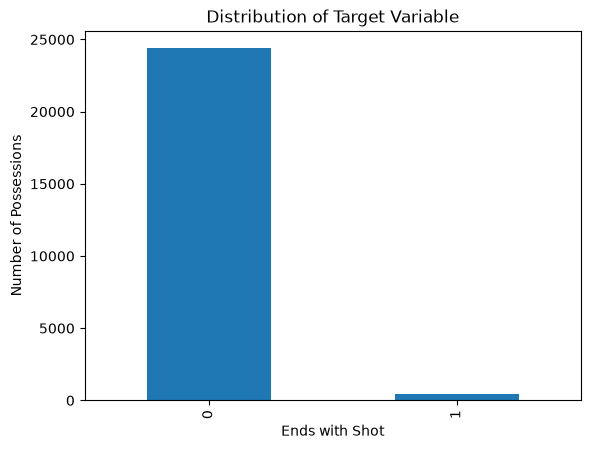

In [23]:
import matplotlib.pyplot as plt

last_events["ends_with_shot"].value_counts().plot.bar()

plt.title("Distribution of Target Variable")
plt.xlabel("Ends with Shot")
plt.ylabel("Number of Possessions")

plt.show()

## Create Possession Dataset

In [17]:
possession_df = possession_lengths.merge(

    last_events[
        [
            "match_id",
            "possession",
            "team",
            "possession_team",
            "type",
            "ends_with_shot"
        ]
    ],

    on=[
        "match_id",
        "possession"
    ],

    how="left"
)

In [21]:
possession_df.duplicated().sum()

np.int64(0)

In [22]:
possession_df.isnull().sum()

match_id           0
possession         0
num_events         0
team               0
possession_team    0
type               0
ends_with_shot     0
dtype: int64

In [18]:
possession_df.head()

,match_id,possession,num_events,team,possession_team,type,ends_with_shot
0,3912592,1,4,Manchester United W,Aston Villa W,Half Start,0
1,3912592,2,21,Manchester United W,Manchester United W,Ball Receipt*,0
2,3912592,3,68,Manchester United W,Aston Villa W,Pressure,0
3,3912592,4,5,Manchester United W,Manchester United W,Foul Won,0
4,3912592,5,28,Manchester United W,Manchester United W,Ball Receipt*,0


In [19]:
possession_df.shape

(24814, 7)

In [20]:
possession_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24814 entries, 0 to 24813
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   match_id         24814 non-null  int64
 1   possession       24814 non-null  int64
 2   num_events       24814 non-null  int64
 3   team             24814 non-null  str  
 4   possession_team  24814 non-null  str  
 5   type             24814 non-null  str  
 6   ends_with_shot   24814 non-null  int64
dtypes: int64(4), str(3)
memory usage: 1.3 MB


In [24]:
possession_df["type"].value_counts()

type
Ball Receipt*        6466
Goal Keeper          2110
Foul Won             1913
Block                1839
Miscontrol           1599
Clearance            1540
Pressure             1486
Dispossessed         1362
Pass                 1016
Duel                  825
Interception          646
Dribble               638
Substitution          444
Shot                  433
Referee Ball-Drop     347
Ball Recovery         279
Half End              264
Tactical Shift        261
Injury Stoppage       248
Player Off            193
Carry                 191
Shield                148
Half Start            132
50/50                 105
Foul Committed         89
Bad Behaviour          82
Player On              60
Dribbled Past          37
Offside                36
Error                  11
Own Goal For            7
Own Goal Against        7
Name: count, dtype: int64

## Save Dataset

In [25]:
possession_df.to_csv(
    "../data/processed/possession_dataset.csv",
    index=False
)

In [26]:
import os

os.path.exists("../data/processed/possession_dataset.csv")

True

In [27]:
possession_dataset = pd.read_csv(
    "../data/processed/possession_dataset.csv"
)

possession_dataset.shape

(24814, 7)

## Conclusion

The event-level StatsBomb dataset was successfully transformed into a possession-level dataset, where each observation represents a single possession.

A binary target variable (`ends_with_shot`) was created to indicate whether a possession resulted in a shot, providing the foundation for the first predictive modeling task.

The resulting dataset was validated, saved locally, and will be used in the following stages of the project for feature engineering, exploratory data analysis, and machine learning model development.